In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.signal import butter, filtfilt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import mne
from glob import glob

In [213]:
# Load dataset
# data = pd.read_csv('data/shivansh_five_class_run_2.csv', header=None)
# print(data.head())

# Load and combine multiple files
# files = [
#     # 'data/EEG_bar_trials_20_classes_3_20251118_164048.csv',
#     # 'data/EEG_bar_trials_20_classes_3_20251118_174039.csv',
#     # 'data/EEG_bar_trials_20_classes_3_20251118_174039.csv',
#     'data/EEG_bar_trials_30_classes_3_20251118_161525.csv'
# ]

# data_list = [pd.read_csv(f) for f in files]
# data = pd.concat(data_list, ignore_index=True)
# print(f"Combined data shape: {data.shape}")

files = sorted(glob('data/EEG_bar_trials_*.csv'))
print(f"Found {len(files)} files:")
for f in files:
    print(f"  - {f}")

if len(files) == 0:
    print("WARNING: No files found! Check your data directory path.")
else:
    data_list = [pd.read_csv(f) for f in files]
    data = pd.concat(data_list, ignore_index=True)
    print(f"Combined data shape: {data.shape}")
    print(f"Unique trials: {data['trial_index'].nunique()}")
    print(f"Unique class labels: {data['class_label'].unique()}")

Found 4 files:
  - data\EEG_bar_trials_20_classes_3_20251118_164048.csv
  - data\EEG_bar_trials_20_classes_3_20251118_174039.csv
  - data\EEG_bar_trials_20_classes_3_20251118_175732.csv
  - data\EEG_bar_trials_30_classes_3_20251118_161525.csv
Combined data shape: (613956, 22)
Unique trials: 91
Unique class labels: [0 2 1 3]
Combined data shape: (613956, 22)
Unique trials: 91
Unique class labels: [0 2 1 3]


In [214]:
def ensure_fixed_length(arr, n_samples=2250, n_channels=8):
    """Ensure a 2D array has exactly n_samples rows and n_channels columns by truncating or padding with zeros.

    - If `arr` is empty, returns zeros of shape (n_samples, n_channels).
    - If `arr` has fewer/more columns than `n_channels`, columns are padded/truncated.
    - If `arr` has fewer rows than `n_samples`, rows are padded; if more, rows are truncated.
    """
    if arr is None or arr.size == 0:
        return np.zeros((n_samples, n_channels), dtype=float)

    rows, cols = arr.shape
    # fix columns
    if cols > n_channels:
        arr = arr[:, :n_channels]
    elif cols < n_channels:
        pad_cols = np.zeros((rows, n_channels - cols), dtype=arr.dtype)
        arr = np.hstack([arr, pad_cols])

    # fix rows
    if rows >= n_samples:
        return arr[:n_samples, :]
    else:
        pad = np.zeros((n_samples - rows, arr.shape[1]), dtype=arr.dtype)
        return np.vstack([arr, pad])


def trails_by_time(data, fs=250, eeg_col_start=5, eeg_col_end=13, n_samples=1000):
    """Build trials with fixed shape (n_samples, n_channels) for the MI (stimulus) phase.
    Returns: trials (N_trials, n_samples, n_channels), trial_labels (N_trials,), trial_splits (N_trials,)
    """
    trials = []
    trial_labels = []
    trial_splits = []
    unique_trials = data['trial_index'].unique()
    print(f'Found {len(unique_trials)} unique trials.')

    # determine EEG columns (keep iloc behavior: columns 5:13 -> typically 8 channels)
    eeg_cols = data.columns[eeg_col_start:eeg_col_end]
    n_channels = len(eeg_cols)

    for trial in unique_trials:
        print(f'Processing trial {trial}...')
        if trial != 0:
            trial_data = data[data['trial_index'] == trial]
            label = trial_data['class_label'].values[0] if 'class_label' in trial_data.columns else None
            split = trial_data['split'].values[0] if 'split' in trial_data.columns else None

            # select MI (stimulus) rows only and extract EEG columns
            trial_MI = trial_data[trial_data['phase'] == 'stimulus']
            eeg_matrix = trial_MI.loc[:, eeg_cols].values if len(trial_MI) > 0 else np.zeros((0, n_channels))

            # ensure exactly n_samples rows and n_channels columns (truncate or pad)
            fixed = ensure_fixed_length(eeg_matrix, n_samples=n_samples, n_channels=n_channels)

            trials.append(fixed)
            trial_labels.append(label)
            trial_splits.append(split)

    trials = np.array(trials)
    trial_labels = np.array(trial_labels)
    trial_splits = np.array(trial_splits)

    print(f'Built {len(trials)} trials -> each trial shape: {trials.shape[1:]}')
    # return trials as (N, n_samples, n_channels)
    return trials, trial_labels, trial_splits

# Run and build trials (explicitly set n_samples to 2250 to trim/pad every trial)
trials, trial_labels, trial_splits = trails_by_time(data, n_samples=1000)


Found 91 unique trials.
Processing trial 0...
Processing trial 1...
Processing trial 2...
Processing trial 3...
Processing trial 4...
Processing trial 5...
Processing trial 6...
Processing trial 7...
Processing trial 8...
Processing trial 9...
Processing trial 10...
Processing trial 11...
Processing trial 12...
Processing trial 13...
Processing trial 14...
Processing trial 15...
Processing trial 16...
Processing trial 17...
Processing trial 18...
Processing trial 19...
Processing trial 20...
Processing trial 21...
Processing trial 22...
Processing trial 23...
Processing trial 24...
Processing trial 25...
Processing trial 26...
Processing trial 27...
Processing trial 28...
Processing trial 29...
Processing trial 30...
Processing trial 31...
Processing trial 32...
Processing trial 33...
Processing trial 34...
Processing trial 35...
Processing trial 36...
Processing trial 37...
Processing trial 38...
Processing trial 39...
Processing trial 40...
Processing trial 41...
Processing trial 42.

In [215]:
# %%
print(f"Total trials: {len(trials)}")
print(f"Class distribution across all trials:")
unique, counts = np.unique(trial_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} trials")

Total trials: 90
Class distribution across all trials:
  Class 1: 31 trials
  Class 2: 27 trials
  Class 3: 32 trials


In [216]:
# Create MI / baseline views (kept for reference)
MI = data[data['phase'] == 'stimulus']
baseline = data[data['phase'] == 'baseline']
print(f'MI Readings shape (rows in raw data): {MI.shape}')
print(f'Baseline Readings shape: {baseline.shape}')

# Show shapes of the built trials
print(f'Number of trials built: {len(trials)}')
if len(trials) > 0:
    print(f'Each trial shape (n_samples, n_channels): {trials.shape[1:]}')

# Convert per-trial data into a stacked continuous array so downstream cells that expect
# `readings`/`labels`/`split` still work without many changes.
# - readings: shape (n_trials * n_samples, n_channels)
# - labels:   repeated trial label per sample -> shape (n_trials * n_samples,)
# - split:    repeated trial split per sample
if len(trials) > 0:
    n_samples = trials.shape[1]
    n_channels = trials.shape[2]
    readings = trials.reshape(-1, n_channels)  # stack trials into continuous samples
    labels = np.repeat(trial_labels, n_samples)
    split = np.repeat(trial_splits, n_samples)

    print(f'Stacked readings shape: {readings.shape}')
    print(f'Stacked labels shape: {labels.shape}')
    print(f'Unique class labels (trials): {np.unique(trial_labels)}')
else:
    print('No trials were built; `readings` will fall back to using raw MI rows')

# If you want to continue using original MI-based readings instead, comment out the stacking above
# and uncomment the following two lines to use the row-wise MI values (not trimmed per-trial):
# readings = MI.iloc[:, 5:13].values
# labels = MI['class_label'].values


MI Readings shape (rows in raw data): (272182, 22)
Baseline Readings shape: (204738, 22)
Number of trials built: 90
Each trial shape (n_samples, n_channels): (1000, 8)
Stacked readings shape: (90000, 8)
Stacked labels shape: (90000,)
Unique class labels (trials): [1 2 3]


In [217]:
# %%
# Balance data per class to use all files equally
from collections import Counter

train_idx = np.where(split == 'train')[0]
test_idx  = np.where(split == 'test')[0]

eeg_train = readings[train_idx]
lbl_train = labels[train_idx]

eeg_test = readings[test_idx]
lbl_test = labels[test_idx]

print("\n=== BEFORE balancing ===")
print(f"Train samples: {eeg_train.shape[0]}")
print(f"Train label distribution: {np.unique(lbl_train, return_counts=True)}")
print(f"Test samples: {eeg_test.shape[0]}")
print(f"Test label distribution: {np.unique(lbl_test, return_counts=True)}")

# Find minimum per class
train_counts = Counter(lbl_train)
test_counts = Counter(lbl_test)

min_train_per_class = min(train_counts.values())
min_test_per_class = min(test_counts.values())

print(f"\nMinimum samples per class in train: {min_train_per_class}")
print(f"Minimum samples per class in test: {min_test_per_class}")

# Balance function
def balance_data(eeg_data, labels_data, min_samples_per_class):
    balanced_eeg = []
    balanced_labels = []
    
    unique_classes = np.unique(labels_data)
    for cls in unique_classes:
        cls_idx = np.where(labels_data == cls)[0]
        selected_idx = np.random.choice(cls_idx, size=min_samples_per_class, replace=False)
        balanced_eeg.append(eeg_data[selected_idx])
        balanced_labels.append(labels_data[selected_idx])
    
    return np.vstack(balanced_eeg), np.concatenate(balanced_labels)

# Apply balancing
eeg_train = balance_data(eeg_train, lbl_train, min_train_per_class)[0]
lbl_train = balance_data(readings[train_idx], labels[train_idx], min_train_per_class)[1]

eeg_test = balance_data(eeg_test, lbl_test, min_test_per_class)[0]
lbl_test = balance_data(readings[test_idx], labels[test_idx], min_test_per_class)[1]

print("\n=== AFTER balancing ===")
print(f"Train samples: {eeg_train.shape[0]}")
print(f"Train label distribution: {np.unique(lbl_train, return_counts=True)}")
print(f"Test samples: {eeg_test.shape[0]}")
print(f"Test label distribution: {np.unique(lbl_test, return_counts=True)}")


=== BEFORE balancing ===
Train samples: 72000
Train label distribution: (array([1, 2, 3]), array([26000, 22000, 24000]))
Test samples: 18000
Test label distribution: (array([1, 2, 3]), array([5000, 5000, 8000]))

Minimum samples per class in train: 22000
Minimum samples per class in test: 5000

=== AFTER balancing ===
Train samples: 66000
Train label distribution: (array([1, 2, 3]), array([22000, 22000, 22000]))
Test samples: 15000
Test label distribution: (array([1, 2, 3]), array([5000, 5000, 5000]))


In [ ]:
# %%
# NEW: operate on whole trials to avoid label leakage and misaligned windows
from collections import Counter

train_mask = trial_splits == 'train'
test_mask = trial_splits == 'test'

eeg_train_trials = trials[train_mask]
lbl_train_trials = trial_labels[train_mask]

eeg_test_trials = trials[test_mask]
lbl_test_trials = trial_labels[test_mask]

print("\n=== Trial-level split ===")
print(f"Train trials: {eeg_train_trials.shape[0]} | distribution: {np.unique(lbl_train_trials, return_counts=True)}")
print(f"Test trials : {eeg_test_trials.shape[0]} | distribution: {np.unique(lbl_test_trials, return_counts=True)}")


def balance_trials(eeg_trials, label_trials):
    counts = Counter(label_trials)
    min_trials = min(counts.values())
    balanced_trials = []
    balanced_labels = []
    for cls in sorted(counts.keys()):
        cls_idx = np.where(label_trials == cls)[0]
        selected = np.random.choice(cls_idx, size=min_trials, replace=False)
        balanced_trials.append(eeg_trials[selected])
        balanced_labels.append(label_trials[selected])
    return np.vstack(balanced_trials), np.concatenate(balanced_labels)


eeg_train_trials, lbl_train_trials = balance_trials(eeg_train_trials, lbl_train_trials)

print("\n=== After balancing train trials ===")
print(f"Train trials: {eeg_train_trials.shape[0]} | distribution: {np.unique(lbl_train_trials, return_counts=True)}")
print(f"Test trials  : {eeg_test_trials.shape[0]} | distribution (kept as-is): {np.unique(lbl_test_trials, return_counts=True)}")



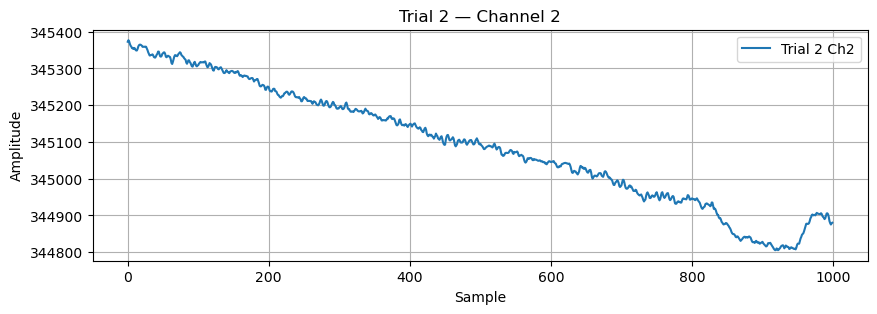

c:\Anaconda\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 1024 is greater than input length  = 1000, using nperseg = 1000
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


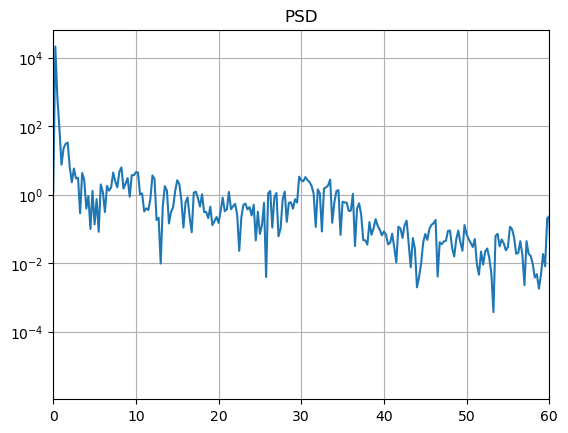

In [218]:
import matplotlib.pyplot as plt
# Show one trial (trial index 0), channel 0
trial_idx = 2
ch = 2
plt.figure(figsize=(10,3))
plt.plot(trials[trial_idx, :, ch], label=f'Trial {trial_idx} Ch{ch}')
plt.title(f'Trial {trial_idx} — Channel {ch}')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# PSD check for same trial/channel
from scipy.signal import welch
f, Pxx = welch(trials[trial_idx, :, ch], fs=250, nperseg=1024)
plt.semilogy(f, Pxx); plt.xlim(0,60); plt.title('PSD'); plt.grid(True); plt.show()

In [219]:
# readings = MI.iloc[:, 5:13].values
# labels = MI['class_label'].values
# split = MI['split'].values
# print(f'Readings shape: {readings.shape}, Labels shape: {labels}')
# left_hand_count = np.sum(labels == 'left_arm')
# upper_data = MI.iloc[labels == 1]
# upper_data_readings = upper_data.iloc[:, 5:13].values

# middle_data = MI.iloc[labels == 2]
# middle_data_readings = middle_data.iloc[:, 5:13].values

# lower_data = MI.iloc[labels == 3]
# lower_data_readings = lower_data.iloc[:, 5:13].values

# print(f'Number of upper data labels: {upper_data_readings}')
# print(f'Number of middle data labels: {middle_data_readings}')
# print(f'Number of lower data labels: {lower_data_readings}')



# print(labels)
# la = []
# ra = []
# rl = []
# ll = []
# s = []
# # assume you already did:
# readings = MI.iloc[:, 5:13].values   # shape (n_samples, n_channels)
# labels   = MI['class_label'].values      # shape (n_samples,)

# s = []
# la = []
# ra = []
# rl = []
# ll = []

# n = len(labels)
# for i in range(n):
#     lbl = labels[i]                      # <- single string label for row i
#     row = readings[i, :]                 # <- 1D array for that sample's 8 channels
#     if lbl == 1:
#         s.append(row)
#     elif lbl == 2:
#         la.append(row)
#     else:
#         ra.append(row)

# # convert to numpy arrays if needed
# s = np.array(s)
# la = np.array(la)
# ra = np.array(ra)
# rl = np.array(rl)
# ll = np.array(ll)

# print(f'label 1 samples: {len(s)}')
# print(f'label 2 samples: {len(la)}')
# print(f'label 3 samples: {len(ra)}')
# print(f'Unique labels: {np.unique(labels)}')
# print(f'Labels distribution:\n{pd.Series(labels).value_counts()}')
# print(readings[:5])

In [220]:
# X_train = readings[split == 'train']
# y_train = labels[split == 'train']
# X_test = readings[split == 'test']
# y_test = labels[split == 'test']
# print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')

In [ ]:

def bandpass_filter(signal, lowcut=4, highcut=40, fs=250, order=4):
    """Apply a zero-phase Butterworth band-pass along the time axis."""
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    # Works for both 1D (samples,) and 2D (samples, channels) tensors
    return filtfilt(b, a, signal, axis=0)


In [222]:


# Verify shape: (n_samples, n_channels)
print("readings.shape:", readings.shape)

fs = 250  # sampling frequency (Hz) - keep this consistent with your data

filtered_readings = np.zeros_like(readings)
for ch_idx in range(readings.shape[1]):  # loop over 8 channels
    raw_signal = readings[:, ch_idx]
    filtered_readings[:, ch_idx] = bandpass_filter(raw_signal, lowcut=4, highcut=40, fs=fs, order=4)

print("filtered_readings shape:", filtered_readings.shape)

readings.shape: (90000, 8)
filtered_readings shape: (90000, 8)


In [ ]:
# %%
print("Using trial-based arrays for filtering...")
fs = 250  # sampling frequency (Hz)

def apply_bandpass(trial_block):
    filtered = np.zeros_like(trial_block)
    for idx in range(trial_block.shape[0]):
        filtered[idx] = bandpass_filter(trial_block[idx], lowcut=4, highcut=40, fs=fs, order=4)
    return filtered


filtered_train = apply_bandpass(eeg_train_trials)
filtered_test = apply_bandpass(eeg_test_trials)

print("filtered_train shape:", filtered_train.shape)
print("filtered_test shape:", filtered_test.shape)



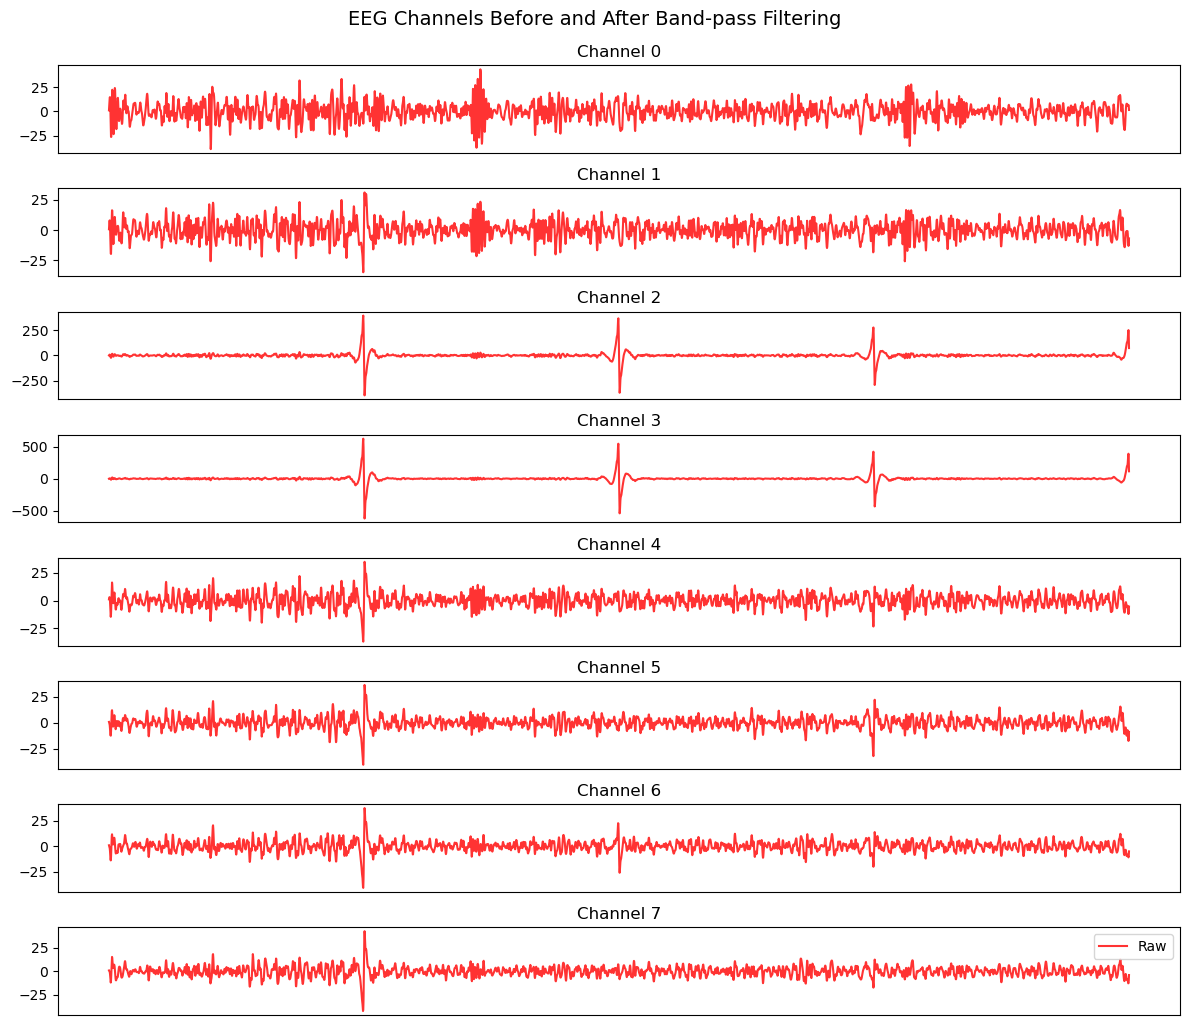

In [ ]:
plt.figure(figsize=(12, 10))
example_raw = eeg_train_trials[0]
example_filtered = filtered_train[0]
for i in range(example_raw.shape[1]):
    plt.subplot(8, 1, i + 1)
    plt.plot(example_raw[:4000, i], color='gray', alpha=0.5, label='Raw')
    plt.plot(example_filtered[:4000, i], color='red', alpha=0.8, label='Filtered')
    plt.title(f"Channel {i}")
    plt.xticks([])
    plt.tight_layout()

plt.legend(['Raw', 'Filtered'], loc='upper right')
plt.suptitle("EEG Channels Before and After Band-pass Filtering", fontsize=14, y=1.02)
plt.show()



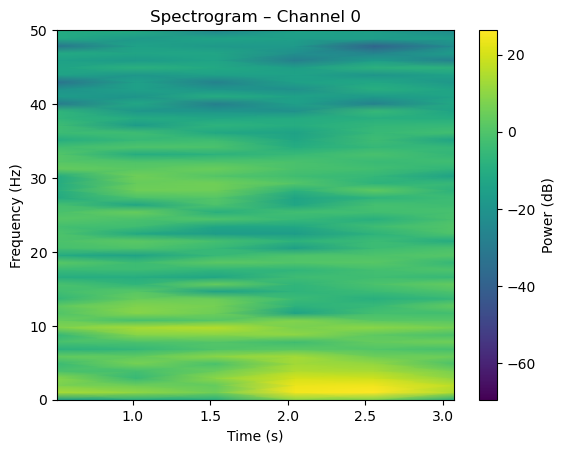

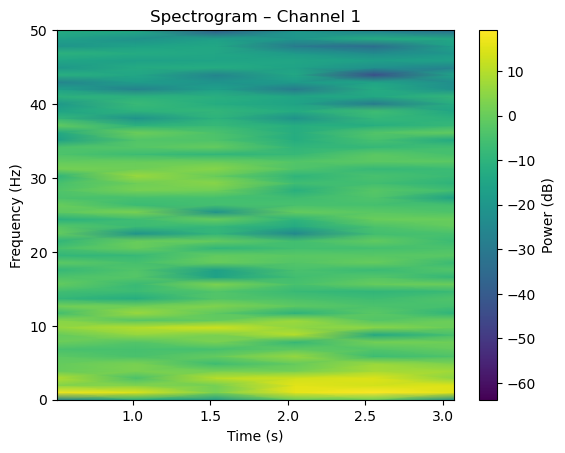

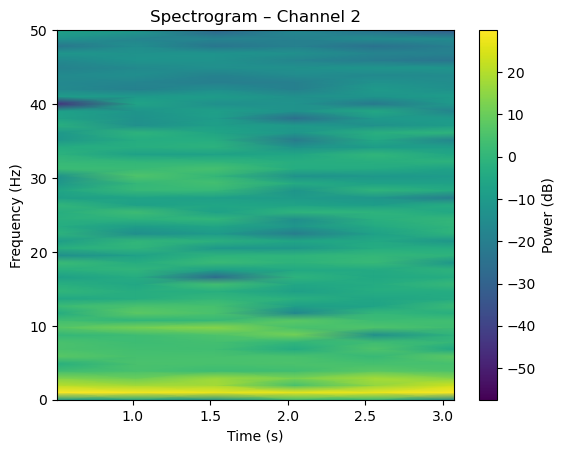

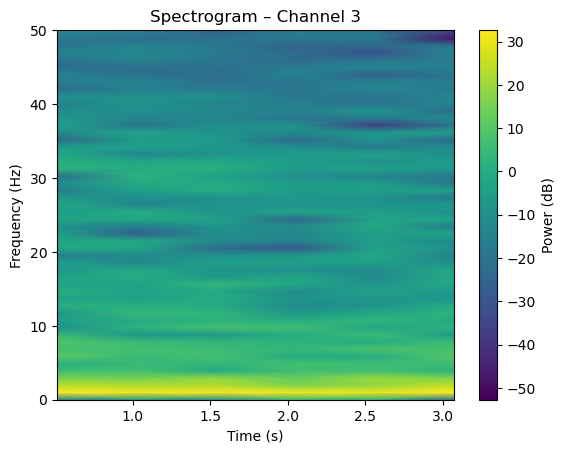

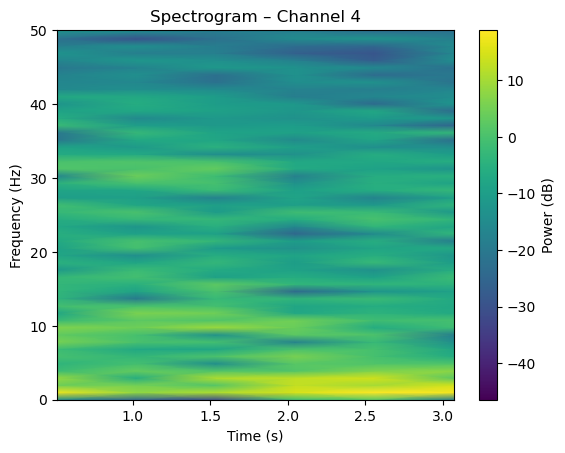

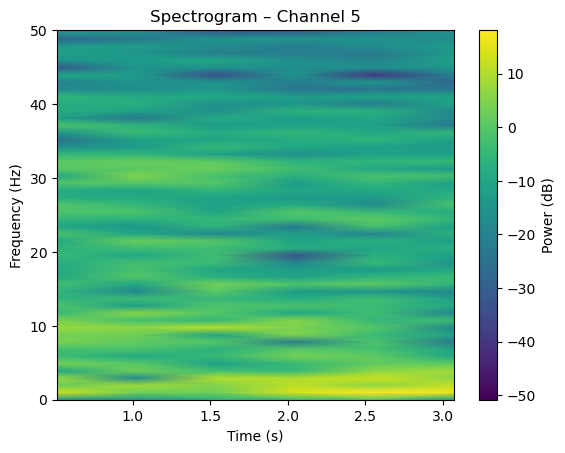

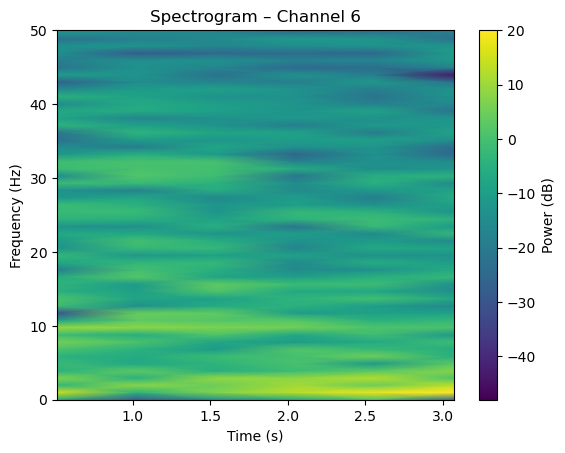

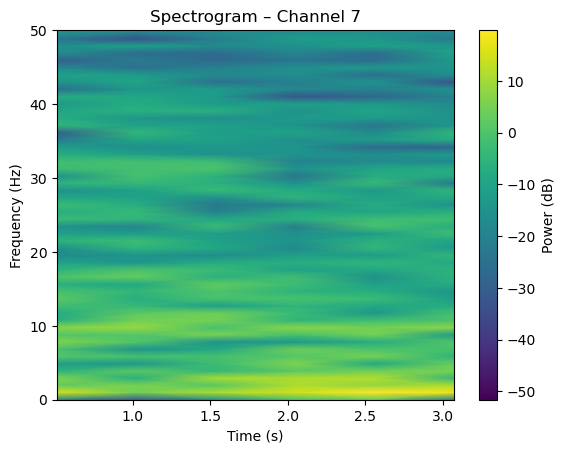

In [224]:
from scipy.signal import spectrogram

ch = 0
for i in range(readings.shape[1]):
    f, t, Sxx = spectrogram(readings[4000:5000, i], fs, nperseg=256, noverlap=128)
    plt.pcolormesh(t, f, 10*np.log10(Sxx), shading='gouraud')
    plt.title(f"Spectrogram – Channel {i}")
    plt.ylabel('Frequency (Hz)')
    plt.xlabel('Time (s)')
    plt.ylim(0, 50)
    plt.colorbar(label='Power (dB)')
    plt.show()




filtered_readings shape: (90000, 8)
Creating RawArray with float64 data, n_channels=8, n_times=90000
    Range : 0 ... 89999 =      0.000 ...   359.996 secs
Ready.
Fitting ICA...
Fitting ICA to data using 8 channels (please be patient, this may take a while)
    Range : 0 ... 89999 =      0.000 ...   359.996 secs
Ready.
Fitting ICA...
Fitting ICA to data using 8 channels (please be patient, this may take a while)
Selecting by number: 8 components
Selecting by number: 8 components


C:\Users\Shivansh Sharma\AppData\Local\Temp\ipykernel_18276\2568199852.py:19: RuntimeWarning: The data has not been high-pass filtered. For good ICA performance, it should be high-pass filtered (e.g., with a 1.0 Hz lower bound) before fitting ICA.
  ica.fit(raw_mne)


Fitting ICA took 0.3s.


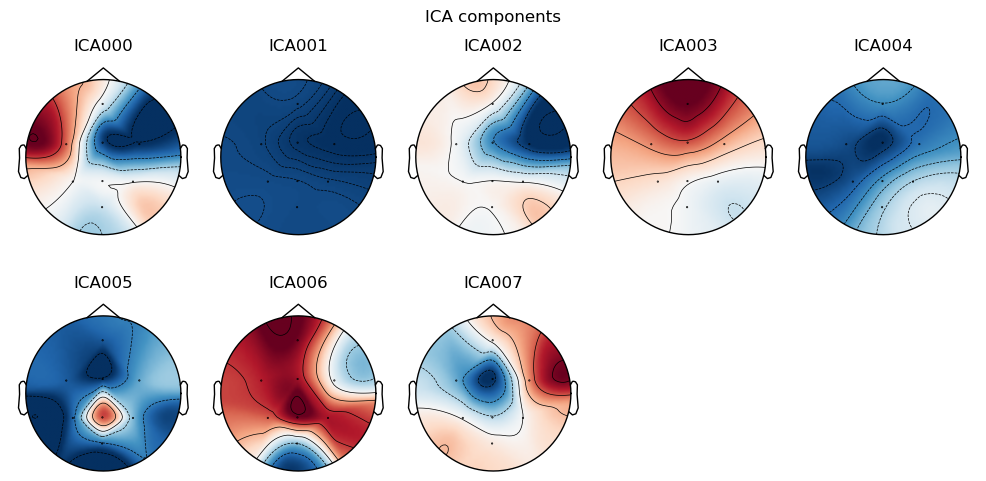

Applying ICA to Raw instance
    Transforming to ICA space (8 components)
    Zeroing out 1 ICA component
    Projecting back using 8 PCA components
    Transforming to ICA space (8 components)
    Zeroing out 1 ICA component
    Projecting back using 8 PCA components
filtered_clean shape: (90000, 8)
filtered_clean shape: (90000, 8)


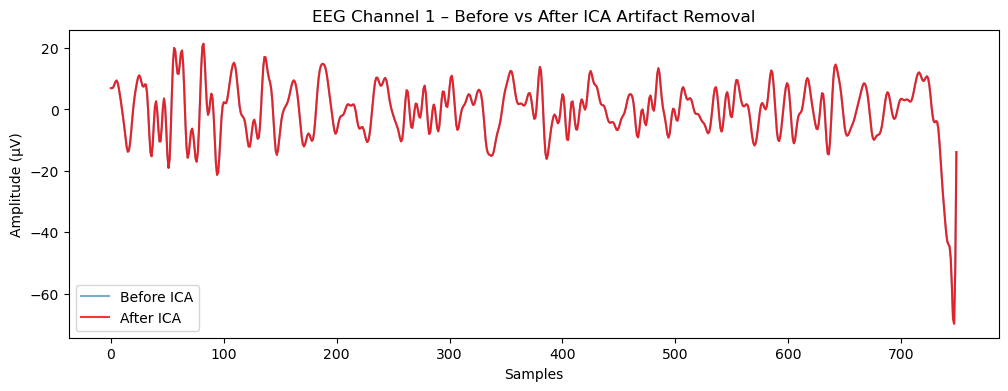

In [225]:
import mne


fs = 250
# Use realistic EEG channel names if possible
ch_names = ['Fz','C3','Cz','C4','P3','Pz','P4','Oz']
ch_types = ['eeg'] * 8
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=ch_types)

print("filtered_readings shape:", filtered_readings.shape)
raw_mne = mne.io.RawArray(filtered_readings.T, info)

# ✅ Add montage to provide electrode positions
montage = mne.channels.make_standard_montage('standard_1020')
raw_mne.set_montage(montage)
# --- Run ICA ---
ica = mne.preprocessing.ICA(n_components=8, random_state=42, max_iter=500)
print("Fitting ICA...")
ica.fit(raw_mne)

# --- Visualize components safely ---
ica.plot_components()  # now works, shows scalp maps
# OR if you only want time-series of activations:
# ica.plot_sources(raw_mne)

# --- Optionally exclude components ---
ica.exclude = [0]  # change after visual inspection
raw_clean = ica.apply(raw_mne)

filtered_clean = raw_clean.get_data().T
print("filtered_clean shape:", filtered_clean.shape)

# --- Quick comparison ---
plt.figure(figsize=(12, 4))
plt.plot(filtered_readings[4250:5000, 0], label='Before ICA', alpha=0.6)
plt.plot(filtered_clean[4250:5000, 0], label='After ICA', color='red', alpha=0.8)
plt.title('EEG Channel 1 – Before vs After ICA Artifact Removal')
plt.xlabel('Samples')
plt.ylabel('Amplitude (µV)')
plt.legend()
plt.show()

In [ ]:
# %%
# ICA fitted on TRAIN only to avoid leakage
import mne

ch_names = ['Fz','C3','Cz','C4','P3','Pz','P4','Oz']
ch_types = ['eeg'] * len(ch_names)
info = mne.create_info(ch_names=ch_names, sfreq=fs, ch_types=ch_types)
montage = mne.channels.make_standard_montage('standard_1020')


def trials_to_raw(trial_block):
    data = trial_block.reshape(-1, trial_block.shape[2]).T
    raw = mne.io.RawArray(data, info.copy())
    raw.set_montage(montage)
    return raw


train_raw = trials_to_raw(filtered_train)
ica = mne.preprocessing.ICA(n_components=len(ch_names), random_state=42, max_iter=500)
print("Fitting ICA on TRAIN trials only...")
ica.fit(train_raw)

train_raw_clean = ica.apply(train_raw.copy())
filtered_train_clean = train_raw_clean.get_data().T.reshape(filtered_train.shape)

test_raw = trials_to_raw(filtered_test)
test_raw_clean = ica.apply(test_raw.copy())
filtered_test_clean = test_raw_clean.get_data().T.reshape(filtered_test.shape)

print("filtered_train_clean shape:", filtered_train_clean.shape)
print("filtered_test_clean shape:", filtered_test_clean.shape)

plt.figure(figsize=(12, 4))
plt.plot(filtered_train[0, :750, 0], label='Before ICA', alpha=0.6)
plt.plot(filtered_train_clean[0, :750, 0], label='After ICA', color='red', alpha=0.8)
plt.title('EEG Channel 0 – Before vs After ICA Artifact Removal')
plt.xlabel('Samples')
plt.ylabel('Amplitude (µV)')
plt.legend()
plt.show()



In [ ]:
# %%
# Standardize channels using TRAIN statistics only
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_flat = filtered_train_clean.reshape(-1, filtered_train_clean.shape[2])
test_flat = filtered_test_clean.reshape(-1, filtered_test_clean.shape[2])

scaler.fit(train_flat)
train_norm = scaler.transform(train_flat).reshape(filtered_train_clean.shape)
test_norm = scaler.transform(test_flat).reshape(filtered_test_clean.shape)

eeg_norm_train = train_norm
eeg_norm_test = test_norm

print("train_norm shape:", eeg_norm_train.shape)
print("test_norm shape:", eeg_norm_test.shape)



In [ ]:
# %%
# Encode labels to 0..N-1
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(np.concatenate([lbl_train_trials, lbl_test_trials]))

lbl_train = label_encoder.transform(lbl_train_trials)
lbl_test = label_encoder.transform(lbl_test_trials)

print("Unique encoded labels (train):", np.unique(lbl_train, return_counts=True))
print("Unique encoded labels (test) :", np.unique(lbl_test, return_counts=True))



In [226]:

scaler = StandardScaler()
eeg_norm = scaler.fit_transform(filtered_readings)  # shape: (n_samples, 8)

print("eeg_norm shape:", eeg_norm)

eeg_norm shape: [[ 0.0828501   0.06727482 -0.01282308 ...  0.07837196  0.08756487
   0.09121496]
 [ 0.39913488  0.31418211  0.31637589 ... -0.00233407 -0.00451017
   0.06099337]
 [ 0.75534655  0.5193772   0.55117109 ... -0.08601794 -0.08178228
   0.03675326]
 ...
 [-0.37656102 -0.30686398 -0.28163846 ... -0.00583097  0.11769559
   0.14910141]
 [-0.1861376  -0.22183782 -0.20070516 ... -0.08098367  0.0071945
   0.04256596]
 [ 0.10907223  0.02689434  0.06559185 ... -0.07214988 -0.04182606
   0.00205835]]


In [227]:
# label_encoder = LabelEncoder()
# labels_encoded = label_encoder.fit_transform(labels)
# print("labels_encoded shape:", labels_encoded)
# print(labels)

# Verify labels are numeric
print("Unique labels before encoding:", np.unique(labels))
print("Labels dtype:", labels.dtype)

# Since labels are already 1, 2, 3 format, just convert to int
labels_encoded = labels.astype(int)
print("labels_encoded shape:", labels_encoded.shape)
print("Unique encoded labels:", np.unique(labels_encoded))
print("Label distribution:", np.unique(labels_encoded, return_counts=True))

Unique labels before encoding: [1 2 3]
Labels dtype: int64
labels_encoded shape: (90000,)
Unique encoded labels: [1 2 3]
Label distribution: (array([1, 2, 3]), array([31000, 27000, 32000]))


In [228]:
# # Split indices for train/test
# train_idx_filtered = np.where(split == 'train')[0]
# test_idx_filtered  = np.where(split == 'test')[0]

# eeg_train_data = eeg_norm[train_idx_filtered]
# lbl_train = labels_encoded[train_idx_filtered]

# eeg_test_data = eeg_norm[test_idx_filtered]
# lbl_test = labels_encoded[test_idx_filtered]

# print("Train samples:", eeg_train_data.shape[0])
# print("Test samples :", eeg_test_data.shape[0])
# print("Train label distribution:", np.unique(lbl_train, return_counts=True))
# print("Test label distribution:", np.unique(lbl_test, return_counts=True))

print("Train samples:", eeg_train.shape[0])
print("Test samples :", eeg_test.shape[0])

Train samples: 66000
Test samples : 15000


In [229]:
# -------------------------------
def create_epochs(eeg_array, labels_array, stride, window, amp_thresh=150):
    X, y = [], []
    for start in range(0, len(eeg_array) - window, stride):
        end = start + window
        epoch = eeg_array[start:end, :]
        epoch_labels = labels_array[start:end]
        # majority label in the window
        majority = np.bincount(epoch_labels).argmax()
        purity = np.mean(epoch_labels == majority)
        if purity >= 0.9 and np.max(np.abs(epoch)) < amp_thresh:
            X.append(epoch)
            y.append(majority)
    return np.array(X), np.array(y)

In [ ]:
# %%
# Override with trial-aware epoching

def create_epochs(trial_block, label_block, stride, window, amp_thresh=150):
    """Slide windows within each trial so labels stay aligned."""
    X, y = [], []
    for trial, label in zip(trial_block, label_block):
        for start in range(0, trial.shape[0] - window + 1, stride):
            epoch = trial[start:start + window, :]
            if np.max(np.abs(epoch)) < amp_thresh:
                X.append(epoch)
                y.append(label)
    return np.array(X), np.array(y)



In [230]:
# train_idx = np.where(split == 'train')[0]
# test_idx  = np.where(split == 'test')[0]

# eeg_train, lbl_train = eeg_norm[train_idx], labels_encoded[train_idx]
# eeg_test,  lbl_test  = eeg_norm[test_idx],  labels_encoded[test_idx]
# print("Train samples:", eeg_train.shape[0])
# print("Test samples :", eeg_test.shape[0])

In [ ]:
# window_sec = 1
# window_size = fs * window_sec          # 250 samples per 1 s
# train_stride = window_size // 2        # 50 % overlap
# test_stride  = window_size             # no overlap
# amp_thresh = 150   

# # X_train, y_train = create_epochs(eeg_train, lbl_train,
# #                                  stride=train_stride, window=window_size)
# # X_test, y_test = create_epochs(eeg_test, lbl_test,
# #                                stride=test_stride, window=window_size)

# X_train, y_train = create_epochs(eeg_train_data, lbl_train,
#                                  stride=train_stride, window=window_size)
# X_test, y_test = create_epochs(eeg_test_data, lbl_test,
#                                stride=test_stride, window=window_size)

# print("Train epochs:", X_train.shape, "Test epochs:", X_test.shape)

window_sec = 1
window_size = fs * window_sec          # 250 samples per 1 s
train_stride = window_size // 2        # 50% overlap
test_stride  = window_size             # no overlap
amp_thresh = 150   

X_train, y_train = create_epochs(eeg_norm_train, lbl_train,
                                 stride=train_stride, window=window_size)
X_test, y_test = create_epochs(eeg_norm_test, lbl_test,
                               stride=test_stride, window=window_size)

print("Train epochs:", X_train.shape, "Test epochs:", X_test.shape)
print("Train epoch labels:", np.unique(y_train, return_counts=True))
print("Test epoch labels:", np.unique(y_test, return_counts=True))

NameError: name 'eeg_norm_train' is not defined

In [211]:
def normalize_epoch(epoch):
    mean = epoch.mean(axis=0, keepdims=True)
    std = epoch.std(axis=0, keepdims=True) + 1e-8
    return (epoch - mean) / std

X_train = np.array([normalize_epoch(e) for e in X_train])
X_test  = np.array([normalize_epoch(e) for e in X_test])

# --- Reshape for CTNet ---
X_train_ctnet = np.transpose(X_train, (0, 2, 1))  # (N, 8, 250)
X_test_ctnet  = np.transpose(X_test,  (0, 2, 1))


print("CTNet train shape:", X_train_ctnet.shape)
print("CTNet test shape:", X_test_ctnet.shape)

CTNet train shape: (520, 8, 250)
CTNet test shape: (71, 8, 250)


In [186]:
np.save("X_train_ctnet.npy", X_train_ctnet)
np.save("y_train_ctnet.npy", y_train)
np.save("X_test_ctnet.npy",  X_test_ctnet)
np.save("y_test_ctnet.npy",  y_test)